# Figure S1: Dataset Comparison (Fragrantica, Aromo, Parfumo)

Side-by-side comparison of three perfume databases (Fragrantica `Fragrantica.csv`, Aromo `Aromo.csv`, Parfumo `Parfumo.csv`). All notes and accords are canonicalised with a shared synonym map before comparison. Saves `output/Figure_S1.pdf` and the summary `output/Table_S1.tex`.

Panels: A coverage by field, B releases per year (1900-2024), C cross-database perfume overlap (brand + name match), D shared-note prevalence per database pair, E note vs accord similarity for matched perfumes, F distribution of notes per perfume.

## 1. Imports and note/accord canonicalisation

In [1]:
# ===========================================================================
import matplotlib as _mpl
_mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif'],
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial', 'mathtext.it': 'Arial:italic', 'mathtext.bf': 'Arial:bold',
    'svg.fonttype': 'path',          
    'pdf.fonttype': 42, 'ps.fonttype': 42,  
})
# ===========================================================================

import os, sys, ast, re, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib_venn import venn3, venn3_circles
import seaborn as sns
from collections import Counter
from scipy.stats import spearmanr

sys.path.append(os.path.abspath(".."))
from utils.utils import parse_notes, parse_average_rating

OUTPUT_DIR = "../output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

NULL_NOTES = {
    '', 'no info', 'none', 'unknown', 'n/a', 'na', 'null'
}

SYNONYM_MAP = {
    'waterlily': 'water lily',
    'sourmilk': 'sour milk',
    'red wood': 'redwood',
    'woodyamber': 'amberwood',
    'bee wax': 'beeswax',
    'ylang ylang': 'ylang ylang',
    'ilang ilang': 'ylang ylang',

    'liquorice': 'licorice',
    'black liquorice': 'black licorice',
    'liquorice root': 'licorice root',
    'liquorice absolute': 'licorice absolute',

    'agarwood (oud)': 'oud',
    'agarwood': 'oud',
    'olibanum (frankincense)': 'frankincense',
    'olibanum': 'frankincense',
    'ambrette (musk mallow)': 'ambrette',
    'curcuma (turmeric)': 'turmeric',
    'curcuma': 'turmeric',
    'lime (linden) blossom': 'linden blossom',
    'carambola (star fruit)': 'star fruit',
    'carambola': 'star fruit',
    'cottonwood (poplar)': 'cottonwood',
    'confetti (sugared almonds)': 'sugared almonds',
    "st. john's wort": "saint john's wort",
    'cypriol oil or nagarmotha': 'nagarmotha',
    'nagarmotha': 'nagarmotha',
    'nagarmota': 'nagarmotha',

    'cloves': 'clove',
    'violets': 'violet',
    'almonds': 'almond',
    'plums': 'plum',
    'citruses': 'citrus',
    'cherry blossoms': 'cherry blossom',
    'peach blossoms': 'peach blossom',
    'orange blossoms': 'orange blossom',
    'apple blossoms': 'apple blossom',
    'candied fruits': 'candied fruit',
    'white woods': 'white wood',
    'dried fruits': 'dried fruit',
    'tobacco leaves': 'tobacco leaf',
    'fig leaves': 'fig leaf',

    'lemon verbena': 'verbena',
    'ceylon cinnamon': 'cinnamon',
    'sea note': 'sea notes',
    'ocean notes': 'sea notes',
    'ocean note': 'sea notes',
    'water note': 'water notes',
    'hedione gedion': 'hedione',
    'embervud amberwood': 'amberwood',
    'embervud _amberwood': 'amberwood',

    'ambergri': 'ambergris',
    'amyri': 'amyris',
    'narciss': 'narcissus',
    'civett': 'civet',
    'amarylli': 'amaryllis',
    'amarilli': 'amaryllis',
    'berrie': 'berries',

    'white ambergri': 'white ambergris',
    'black ambergri': 'black ambergris',
    'indian ambergri': 'indian ambergris',
    'baltic ambergri': 'baltic ambergris',
    'irish white ambergri': 'irish white ambergris',
    'brown ambergri': 'brown ambergris',
    'new zealand ambergri': 'new zealand ambergris',
    'omanian ambergri': 'omani ambergris',
    'irish ambergri': 'irish ambergris',
    'russian ambergri': 'russian ambergris',
    'mozambican ambergri': 'mozambican ambergris',

    'haitian amyri': 'haitian amyris',
    'dominican amyri': 'dominican amyris',
    'jamaican amyri': 'jamaican amyris',
    'caribbean amyri': 'caribbean amyris',

    'florentine iri': 'florentine iris',
    'white iri': 'white iris',
    'blue iri': 'blue iris',
    'italian iri': 'italian iris',
    'yellow iri': 'yellow iris',
    'french iri': 'french iris',
    'black iri': 'black iris',
    'purple iri': 'purple iris',
    'wild iri': 'wild iris',
    'siberian iri': 'siberian iris',
    'tuscan white iri': 'tuscan white iris',
    'lebanese iri': 'lebanese iris',
    'belyy iris iris florentina': 'florentine iris',

    'red berrie': 'red berries',
    'wild berrie': 'wild berries',
    'dried berrie': 'dried berries',
    'goji berrie': 'goji berries',
    'frosted berrie': 'frosted berries',
    'longan berrie': 'longan berries',

    'white amarylli': 'white amaryllis',

    "priest's clothe": "priest's clothes",
    'toluansky balm': 'tolu balsam',

    'sandal': 'sandalwood',
    'vanil': 'vanilla',
    'ambra': 'amber',
    'pachuli': 'patchouli',
    'kedr': 'cedar',
    'mandarin': 'mandarin orange',
    'drevesnyje noty': 'woody notes',
    'apelsinovyj cvet flerdoranzh': 'orange blossom',
    'dubovyj moh': 'oakmoss',
    'ladan': 'incense',
    'kozha': 'leather',
    'frezija': 'freesia',
    'tuberoza': 'tuberose',
    'jabloko': 'apple',
    'gardenija': 'gardenia',
    'grusha': 'pear',
    'tabak': 'tobacco',
    'magnolija': 'magnolia',
    'rozmarin': 'rosemary',
    'anana': 'pineapple',
    'sliva': 'plum',
    'geliotrop': 'heliotrope',
    'morskije noty': 'marine notes',
    'voda': 'water',
    'guajak': 'guaiac wood',
    'list fialki': 'violet leaf',
    'karamel': 'caramel',
    'ptitgrejn list citrusovyh': 'petitgrain',
    'palisander': 'rosewood',
    'artemizija polyn': 'wormwood',
    'loto': 'lotus',
    'mindal': 'almond',
    'dyna': 'melon',
    'zelenoje jabloko': 'green apple',
    'abriko': 'apricot',
    'zhasmin sambak': 'jasmine sambac',
    'trava': 'grass',
    'chaj': 'tea',
    'lichi': 'lychee',
    'klubnika': 'strawberry',
    'timjan': 'thyme',
    'inzhir': 'fig',
    'jezhevika': 'blackberry',
    'ambretta': 'ambrette',
    'marakuja': 'passionfruit',
    'list i buton chernoj smorodiny': 'black currant bud',
    'rom': 'rum',
    'mozhzhevelnik plody': 'juniper berries',
    'sahar': 'sugar',
    'granat': 'pomegranate',
    'romashka': 'chamomile',
    'reven': 'rhubarb',
    'zamsha': 'suede',
    'vishna': 'cherry',
    'damask rose rosa damascena': 'damask rose',
    'arbuz': 'watermelon',
    'jabloko krasnoje': 'red apple',
    'taragon': 'tarragon',
    'shokolad': 'chocolate',
    'dagil': 'angelica',
    'kastoreum': 'castoreum',
    'seno': 'hay',
    'gibiskus': 'hibiscus',
    'krasnye frukty': 'red fruits',
    'ogurec': 'cucumber',
    'moloko': 'milk',
    'tropicheskije frukty': 'tropical fruits',
    'lesnoj oreh': 'hazelnut',
    'aromaticheskie noty': 'aromatic notes',
    'shiprovye noty': 'chypre notes',
    'perechnaja mata': 'peppermint',
    'morskije vodorosli': 'seaweed',
    'pchelinyj vosk': 'beeswax',
    'yagody': 'berries',
    'jablonevyj cvet': 'apple blossom',
    'temnyj shokolad': 'dark chocolate',
    'list inzhira': 'fig leaf',
    'mirta': 'myrtle',
    'kivi': 'kiwi',
    'nektarin': 'nectarine',
    'vishnevyj cvet': 'cherry blossom',
    'saharnaja vata': 'cotton candy',
    'mahagony': 'mahogany',
    'vanilnaja orkhideja': 'vanilla orchid',
    'krasnaja smorodina': 'red currant',
    'paporotnik': 'fern',
    'vinograd': 'grape',
    'fuzhernye noty': 'fougere notes',
    'plushh': 'ivy',
    'visterija': 'wisteria',
    'zhasmin grandiflorum': 'jasmine grandiflorum',
    'klukva': 'cranberry',
    'papaja': 'papaya',
    'chernika': 'blueberry',
    'kokosovoe molochko': 'coconut milk',
    'animalisticheskie noty': 'animalic notes',
    'buton chernoj smorodiny': 'black currant bud',
    'suhofrukty': 'dried fruits',
    'bojaryshnik': 'hawthorn',
    'ris': 'rice',
    'belyy persik': 'white peach',
    'ajva': 'quince',
    'koren fialki': 'orris root',
    'fenkhel': 'fennel',
    'strastocvet': 'passion flower',
    'kalendula ili nogotki': 'calendula',
    'gurjan balm': 'gurjum balsam',
    'zemlanika': 'wild strawberry',
    'dushistyj goroshek': 'sweet pea',
    'lesnyje jagody': 'forest berries',
    'akacija': 'acacia',
    'korichnevyj sahar': 'brown sugar',
    'klever': 'clover',
    'krasniy mak': 'poppy',
    'polevyje cvety': 'field flowers',
    'vzbitye slivki': 'whipped cream',
    'smorodina': 'currant',
    'belyj tabak': 'white tobacco',
    'cvetok mindala': 'almond blossom',
    'list limona': 'lemon leaf',
    'belyj shokolad': 'white chocolate',
    'list pomidora': 'tomato leaf',
    'kolokolchik': 'bluebell',
    'cvetok limona': 'lemon blossom',
    'tulpan': 'tulip',
    'sakharnyy trostnik': 'sugar cane',
    'slivki': 'cream',
    'ekzoticheskije cvety': 'exotic flowers',
    'karambola': 'star fruit',
    'shipovnik': 'rosehip',
    'rozovyy pion': 'pink peony',
    'banan': 'banana',
    'list apelsina': 'orange leaf',
    'majoran': 'marjoram',
    'cvetok khlopka': 'cotton flower',
    'palmaroza': 'palmarosa',
    'zelenyj perec': 'green pepper',
    'cvetok slivy': 'plum blossom',
    'fistashki': 'pistachio',
    'kostus': 'costus',
    'kamelija': 'camellia',
    'tykva': 'pumpkin',
    'zavarnoj krem': 'custard',
    'needles cedar': 'cedar needles',
    'boronija': 'boronia',
    'vodyanoy zhasmin': 'water jasmine',
    'durman': 'thorn apple',
    'olivki': 'olives',
    'kalamus': 'calamus',
    'chernaja orkhideja': 'black orchid',
    'dikije travy': 'wild grasses',
    'drok': 'broom',
    'rezeda': 'mignonette',
    'podsolnechnik': 'sunflower',
    'finiki': 'dates',
    'chereshna': 'sweet cherry',
    'vodanoj giacint': 'water hyacinth',
    'belyy loto': 'white lotus',
    'morkov': 'carrot',
    'klenovyj sirop': 'maple syrup',
    'tsvetok imbirya': 'ginger flower',
    'slivochnoje maslo': 'butter',
    'pirozhnoje': 'cake',
    'greckij oreh': 'walnut',
    'pochva': 'soil',

    'no info': None,
}

def normalize_note(name):
    """Normalize raw note text: lowercase, strip accents, collapse whitespace."""
    if name is None:
        return None
    s = str(name).strip().lower()
    if not s:
        return None
    s = s.replace("\u2019", "'").replace("`", "'")
    s = s.replace("\u00ae", "").replace("\u2122", "")
    s = ''.join(
        c for c in unicodedata.normalize("NFKD", s)
        if not unicodedata.combining(c)
    )
    s = re.sub(r"[-_/]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    if s in NULL_NOTES:
        return None
    return s

def canonicalize_note(name):
    """Normalize + map to canonical form via SYNONYM_MAP."""
    s = normalize_note(name)
    if s is None:
        return None

    if s in SYNONYM_MAP:
        return SYNONYM_MAP[s]

    if len(s) > 4 and s.endswith('s') and not s.endswith(('ss', 'us', 'is')):
        singular = s[:-1]
        if singular in SYNONYM_MAP:
            return SYNONYM_MAP[singular]

    if len(s) > 5 and s.endswith('ies'):
        singular_y = s[:-3] + 'y'
        if singular_y in SYNONYM_MAP:
            return SYNONYM_MAP[singular_y]

    return s

def canonicalize_many(items):
    out = []
    for item in items:
        canon = canonicalize_note(item)
        if canon is not None:
            out.append(canon)
    return out

def split_and_canonicalize(value):
    if pd.isna(value):
        return []
    return canonicalize_many(str(value).split(','))

def parse_aromo_list(value):
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text or text == '[]':
        return []
    try:
        parsed = ast.literal_eval(text)
    except Exception:
        parsed = None
    if isinstance(parsed, list):
        items = parsed
    else:
        items = text.split(',')
    cleaned = []
    for item in items:
        token = str(item).strip().strip("'").strip('"').strip()
        if token:
            cleaned.append(token)
    return cleaned

def join_or_nan(items):
    return ', '.join(items) if items else np.nan

## 2. Load and standardise the three datasets

Reduces each dataset to a common representation: per-perfume canonical note/accord lists, a (brand, name) match key, release year, a rating on a common 1-10 scale, and coverage counts. Parfumo's stray header rows and duplicate URLs are removed first.

In [2]:
fg = pd.read_csv("../dataset/Fragrantica.csv")
fg["year"] = pd.to_numeric(fg["year"], errors="coerce")

ar = pd.read_csv("../dataset/Aromo.csv", sep=",", encoding="utf-8-sig", low_memory=False)
ar["year"] = pd.to_numeric(ar["year"], errors="coerce")
ar["rating_value_num"] = pd.to_numeric(
    ar["rating_value"].astype(str).str.replace(",", ".", regex=False), errors="coerce")
ar["rating_count_num"] = pd.to_numeric(
    ar["rating_count"].astype(str).str.extract(r"(\d+)", expand=False), errors="coerce").fillna(0)
ar["rating_present"] = ar["rating_count_num"] > 0
for col in ["families", "top_notes", "middle_notes", "bottom_notes", "perfumers"]:
    ar[f"{col}_list"] = ar[col].apply(parse_aromo_list)
ar["all_notes_list"] = ar.apply(
    lambda r: r["top_notes_list"] + r["middle_notes_list"] + r["bottom_notes_list"], axis=1)

pm = pd.read_csv("../dataset/Parfumo.csv", low_memory=False)
pm = pm[pm["Name"] != "Name"]
pm = pm.drop_duplicates()
pm = pm.drop_duplicates(subset=("URL" if "URL" in pm.columns else "Number"))
pm["Release_Year"] = pd.to_numeric(pm["Release_Year"], errors="coerce")
pm["Rating_Value"] = pd.to_numeric(pm["Rating_Value"], errors="coerce")

fg["note_list"] = fg["notes"].apply(lambda s: canonicalize_many(parse_notes(s)))
ar["note_list"] = ar["all_notes_list"].apply(canonicalize_many)
pm["note_list"] = pm.apply(
    lambda r: split_and_canonicalize(r["Top_Notes"])
            + split_and_canonicalize(r["Middle_Notes"])
            + split_and_canonicalize(r["Base_Notes"]), axis=1)

def _fg_accords(s):
    try:
        d = ast.literal_eval(s)
        if isinstance(d, dict):
            return canonicalize_many(d.keys())
    except Exception:
        pass
    return []
fg["acc_list"] = fg["accords"].apply(_fg_accords)
ar["acc_list"] = ar["families_list"].apply(canonicalize_many)
pm["acc_list"] = pm["Main_Accords"].apply(split_and_canonicalize)

def match_norm(s):
    """Lowercase, strip accents/punctuation, collapse whitespace."""
    if pd.isna(s):
        return ""
    s = unicodedata.normalize("NFKD", str(s).lower().strip())
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = re.sub(r"[^\w\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def key_set(df, brand_col, name_col):
    k = df[brand_col].apply(match_norm) + "|||" + df[name_col].apply(match_norm)
    return set(k[k != "|||"])

fg["avg_rating"] = fg["rating"].apply(parse_average_rating)
fg_rating10 = fg.loc[fg["avg_rating"] > 0, "avg_rating"] * 2
ar_rating10 = ar.loc[ar["rating_present"], "rating_value_num"] * 2
pm_rating10 = pm.loc[pm["Rating_Value"] > 0, "Rating_Value"]

def note_counter(series):
    c, n = Counter(), 0
    for lst in series:
        if lst:
            n += 1
            c.update(lst)
    return c, n

ORDER  = ["Fragrantica", "Aromo", "Parfumo"]
COLORS = {"Fragrantica": "#4C72B0", "Aromo": "#DD8452", "Parfumo": "#55A868"}

DATASET_COLS = [
    ("Fragrantica", fg, "brand", "perfume name"),
    ("Aromo",       ar, "brand", "name"),
    ("Parfumo",     pm, "Brand", "Name"),
]

DATA = {}
for name, df, brand, nm in DATASET_COLS:
    nc, n_notes = note_counter(df["note_list"])
    ac, n_acc   = note_counter(df["acc_list"])
    DATA[name] = dict(color=COLORS[name], n=len(df),
                      note_counter=nc, n_with_notes=n_notes,
                      acc_counter=ac, n_with_acc=n_acc,
                      note_counts=[len(x) for x in df["note_list"] if x],
                      keys=key_set(df, brand, nm))

PAIRS = [("Fragrantica", "Aromo"), ("Fragrantica", "Parfumo"), ("Aromo", "Parfumo")]

def _keyed_frame(df, brand_col, name_col):
    k = df[brand_col].apply(match_norm) + "|||" + df[name_col].apply(match_norm)
    out = pd.DataFrame({"match_key": k,
                        "notes": df["note_list"].apply(set),
                        "accs":  df["acc_list"].apply(set)})
    return out[out["match_key"] != "|||"].drop_duplicates("match_key")

KEYED = {name: _keyed_frame(df, brand, nm) for name, df, brand, nm in DATASET_COLS}

def jaccard_arrays(a, b):
    """For perfumes matched on (brand, name): Jaccard of canonical notes and accords."""
    m = KEYED[a].merge(KEYED[b], on="match_key", suffixes=("_a", "_b"))
    notes_j = [len(x & y) / len(x | y) for x, y in zip(m["notes_a"], m["notes_b"]) if x and y]
    acc_j   = [len(x & y) / len(x | y) for x, y in zip(m["accs_a"],  m["accs_b"])  if x and y]
    return np.array(notes_j), np.array(acc_j)

MATCHED = {pair: jaccard_arrays(*pair) for pair in PAIRS}

# -- Word2Vec cosine similarity of matched perfumes' note centroids (per pair) --
import gensim.downloader as _api
print("Loading Word2Vec (Google-News-300) for panel E ...")
_w2v = _api.load('word2vec-google-news-300')
_veccache = {}
def _note_vec(note):
    if note not in _veccache:
        ws = str(note).replace('-', ' ').replace('/', ' ').split()
        vv = [_w2v[w] for w in ws if w in _w2v]
        _veccache[note] = np.mean(vv, axis=0) if vv else None
    return _veccache[note]
def _centroid(notes):
    vv = [_note_vec(x) for x in notes]; vv = [v for v in vv if v is not None]
    return np.mean(vv, axis=0) if vv else None
def _cos(u, v):
    nu, nv = np.linalg.norm(u), np.linalg.norm(v)
    return float(np.dot(u, v) / (nu * nv)) if (nu > 0 and nv > 0) else np.nan
def w2v_sim_arrays(a, b, col="notes"):
    m = KEYED[a].merge(KEYED[b], on="match_key", suffixes=("_a", "_b"))
    out = []
    for x, y in zip(m[col + "_a"], m[col + "_b"]):
        if x and y:
            cu, cv = _centroid(x), _centroid(y)
            if cu is not None and cv is not None:
                out.append(_cos(cu, cv))
    return np.array(out)
MATCHED_W2V     = {pair: w2v_sim_arrays(*pair, col="notes") for pair in PAIRS}
MATCHED_W2V_ACC = {pair: w2v_sim_arrays(*pair, col="accs")  for pair in PAIRS}
print("Panel E Word2Vec cosine (matched perfumes):")
for (a, b) in PAIRS:
    print(f"  {a[:4]}-{b[:4]}: notes median={np.median(MATCHED_W2V[(a,b)]):.3f} | "
          f"accords median={np.median(MATCHED_W2V_ACC[(a,b)]):.3f}")

COVERAGE = {
    "Fragrantica": [len(fg), fg["year"].notna().sum(),
                    (fg["rating"].notna() & (fg["rating"] != "{}")).sum(),
                    (fg["accords"].notna() & (fg["accords"] != "{}")).sum(),
                    (fg["notes"].notna() & (fg["notes"] != "[]")).sum(),
                    fg["perfumer"].notna().sum()],
    "Aromo": [len(ar), ar["year"].notna().sum(), int(ar["rating_present"].sum()),
              int(ar["families_list"].apply(bool).sum()),
              int(ar["all_notes_list"].apply(bool).sum()),
              int(ar["perfumers_list"].apply(bool).sum())],
    "Parfumo": [len(pm), pm["Release_Year"].notna().sum(),
                pm["Rating_Value"].notna().sum(), pm["Main_Accords"].notna().sum(),
                (pm["Top_Notes"].notna() | pm["Middle_Notes"].notna() | pm["Base_Notes"].notna()).sum(),
                pm["Perfumers"].notna().sum()],
}
COVERAGE_CATS = ["Total entries", "With year", "With rating",
                 "With accords", "With notes", "With perfumer"]

def yearly_counts(years):
    y = years[(years >= 1900) & (years <= 2024)]
    return y.value_counts().reindex(range(1900, 2025), fill_value=0).sort_index()

YEARLY = {
    "Fragrantica": yearly_counts(fg["year"]),
    "Aromo":       yearly_counts(ar["year"]),
    "Parfumo":     yearly_counts(pm["Release_Year"]),
}

print(f"Fragrantica : {len(fg):,} perfumes")
print(f"Aromo       : {len(ar):,} perfumes")
print(f"Parfumo     : {len(pm):,} perfumes")
print("\nCoverage (entries with field):")
print(pd.DataFrame({k: [f"{int(x):,}" for x in COVERAGE[k]] for k in ORDER}, index=COVERAGE_CATS))
print("\nMean rating (1-10 scale):")
print(f"  Fragrantica {fg_rating10.mean():.2f}   Aromo {ar_rating10.mean():.2f}   Parfumo {pm_rating10.mean():.2f}")

Loading Word2Vec (Google-News-300) for panel E ...
Panel E Word2Vec cosine (matched perfumes):
  Frag-Arom: notes median=0.988 | accords median=0.648
  Frag-Parf: notes median=0.970 | accords median=0.837
  Arom-Parf: notes median=0.967 | accords median=0.639
Fragrantica : 92,589 perfumes
Aromo       : 78,409 perfumes
Parfumo     : 59,280 perfumes

Coverage (entries with field):
              Fragrantica   Aromo Parfumo
Total entries      92,589  78,409  59,280
With year          76,632  31,619  38,984
With rating        92,589  37,006  30,027
With accords       90,806  72,846  32,196
With notes         90,934  72,846  31,152
With perfumer      39,700   6,320  20,530

Mean rating (1-10 scale):
  Fragrantica 7.92   Aromo 7.84   Parfumo 7.35


## 3. Figure panel functions

Each panel is a function that draws into a supplied `ax`, so standalone panels and the combined figure share the same code. Titles are omitted; panels are identified by the bold letters A-F.

In [3]:
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "svg.fonttype": "path",
    "font.family": "sans-serif", "font.size": 11,
    "axes.labelsize": 12, "axes.titlesize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 9,
    "axes.linewidth": 0.9, "axes.edgecolor": "#333333",
})

def _full_box(ax):
    """Show all four spines (full box frame) — applied to every panel."""
    for s in ax.spines.values():
        s.set_visible(True)
        s.set_linewidth(0.9)
        s.set_edgecolor("#333333")

def panel_A(ax):
    cats = ["Total\nentries", "With\nyear", "With\nrating",
            "With\naccords", "With\nnotes", "With\nperfumer"]
    x, w = np.arange(len(cats)), 0.27
    for i, k in enumerate(ORDER):
        ax.bar(x + (i - 1) * w, [c / 1e3 for c in COVERAGE[k]], w, label=k,
               color=COLORS[k], alpha=0.9, edgecolor="white", linewidth=0.4)
    ax.set_ylabel(r"Entries ($\mathrm{\times 10^3}$)")
    ax.set_xticks(x); ax.set_xticklabels(cats, fontsize=8.5)
    ax.legend(frameon=False, fontsize=8.5, loc="upper right")
    _full_box(ax)

def panel_B(ax):
    for k in ORDER:
        ax.plot(YEARLY[k].index, YEARLY[k].values, color=COLORS[k], lw=1.8, alpha=0.9, label=k)
        ax.fill_between(YEARLY[k].index, YEARLY[k].values, alpha=0.10, color=COLORS[k])
    ax.set_yscale("symlog", linthresh=1)
    ax.set_xlim(1900, 2024)
    ax.set_xlabel("Year"); ax.set_ylabel("Perfumes Released")
    ax.legend(frameon=False, loc="upper left")
    _full_box(ax)

def panel_C(ax):
    sets = [DATA[k]["keys"] for k in ORDER]
    v = venn3(sets, set_labels=ORDER, set_colors=[COLORS[k] for k in ORDER], alpha=0.55, ax=ax)
    venn3_circles(sets, linestyle="-", linewidth=0.8, color="gray", ax=ax)
    for t in v.set_labels:
        if t: t.set_fontsize(10); t.set_fontweight("bold")
    for t in v.subset_labels:
        if t: t.set_fontsize(8)
    ax.set_aspect("equal")
    ax.margins(0.08)
    ax.set_xticks([]); ax.set_yticks([])
    _full_box(ax)

def _shared_note_frame(a, b):
    ca, cb = DATA[a]["note_counter"], DATA[b]["note_counter"]
    shared = set(ca) & set(cb)
    return pd.DataFrame({
        "note": list(shared),
        "xa": [ca[n] / DATA[a]["n_with_notes"] * 100 for n in shared],
        "yb": [cb[n] / DATA[b]["n_with_notes"] * 100 for n in shared],
    })

def panel_D(ax):
    styles = [("Fragrantica", "Aromo",   "o", "#1b9e77"),
              ("Fragrantica", "Parfumo", "^", "#d95f02"),
              ("Aromo",       "Parfumo", "s", "#7570b3")]
    mx = 0.0
    for a, b, mk, col in styles:
        d = _shared_note_frame(a, b)
        rho, _ = spearmanr(d["xa"], d["yb"])
        ax.scatter(d["xa"], d["yb"], s=15, marker=mk, alpha=0.45,
                   facecolor=col, edgecolor="none",
                   label=f"{a}–{b}  ($\\rho$={rho:.2f}, n={len(d)})")
        mx = max(mx, d["xa"].max(), d["yb"].max())
    ax.plot([0, mx * 1.05], [0, mx * 1.05], "--", color="gray", lw=1, alpha=0.7)
    ax.set_xlabel("Note Prevalence, 1st Database (% of perfumes)")
    ax.set_ylabel("Note Prevalence, 2nd Database (% of perfumes)")
    ax.legend(frameon=False, fontsize=7, loc="lower right", handletextpad=0.1)
    # mark musk / vetiver / oud in ALL THREE pair-series; one label per note, lines to each point
    import matplotlib.patheffects as pe
    _frames = [_shared_note_frame(a, b).set_index("note") for a, b, _mk, _col in styles]
    for _nm, _ux, _uy in [("musk", -1.2, 0.8), ("vetiver", 1.1, -1.2), ("oud", 1.4, 0.5)]:
        _pts = []
        for _fr in _frames:
            if _nm in _fr.index:
                _x, _y = _fr.at[_nm, "xa"], _fr.at[_nm, "yb"]
                _pts.append((_x, _y))
                ax.scatter([_x], [_y], s=30, facecolor="none", edgecolor="black", linewidth=1.1, zorder=5)
        if not _pts:
            continue
        _cx = sum(q[0] for q in _pts) / len(_pts); _cy = sum(q[1] for q in _pts) / len(_pts)
        _off = 0.1 * mx
        _tx, _ty = _cx + _ux * _off, _cy + _uy * _off
        for _x, _y in _pts:                                  # a line from the single label to each comparison's point
            ax.plot([_tx, _x], [_ty, _y], color="dimgray", lw=0.7, zorder=4)
        ax.text(_tx, _ty, _nm, ha=("left" if _ux >= 0 else "right"), va="center",
                fontsize=8, fontweight="bold", zorder=6,
                path_effects=[pe.withStroke(linewidth=2.0, foreground="white")])
    _full_box(ax)

def panel_E(ax):
    from matplotlib.patches import Patch
    labels = ["Frag–Aromo", "Frag–Parf", "Aromo–Parf"]
    nj = [MATCHED[p][0] for p in PAIRS]
    aj = [MATCHED[p][1] for p in PAIRS]
    nw = [MATCHED_W2V[p] for p in PAIRS]
    aw = [MATCHED_W2V_ACC[p] for p in PAIRS]
    pos, w = np.arange(len(PAIRS)), 0.2
    def _sty(bp, col, al):
        for box in bp["boxes"]: box.set_facecolor(col); box.set_alpha(al)
    b1 = ax.boxplot(nj, positions=pos - 1.5 * w, widths=w * 0.9, patch_artist=True, showfliers=False, medianprops=dict(color="black", lw=1.3))
    b2 = ax.boxplot(aj, positions=pos - 0.5 * w, widths=w * 0.9, patch_artist=True, showfliers=False, medianprops=dict(color="black", lw=1.3))
    ax2 = ax.twinx()
    b3 = ax2.boxplot(nw, positions=pos + 0.5 * w, widths=w * 0.9, patch_artist=True, showfliers=False, medianprops=dict(color="black", lw=1.3))
    b4 = ax2.boxplot(aw, positions=pos + 1.5 * w, widths=w * 0.9, patch_artist=True, showfliers=False, medianprops=dict(color="black", lw=1.3))
    _sty(b1, "#2a9d8f", 0.65); _sty(b2, "#e9a13b", 0.85); _sty(b3, "#7B6FB0", 0.75); _sty(b4, "#5b8fc9", 0.75)
    ax.set_xticks(pos); ax.set_xticklabels(labels, fontsize=8.5)
    ax.set_xlim(-0.6, len(PAIRS) - 0.4)
    ax.set_ylim(-0.03, 1.03)
    ax.set_ylabel("Jaccard Similarity")
    _wall = np.concatenate([d for d in (nw + aw) if len(d)]) if any(len(d) for d in (nw + aw)) else np.array([0.0, 1.0])
    ax2.set_ylim(min(0.0, float(_wall.min())) - 0.02, 1.02)
    ax2.set_ylabel("Word2Vec cosine similarity", color="#5b4e94")
    ax2.tick_params(axis="y", colors="#5b4e94")
    ax.legend(handles=[Patch(facecolor="#2a9d8f", alpha=0.65, label="Notes (Jaccard)"),
                       Patch(facecolor="#e9a13b", alpha=0.85, label="Accords (Jaccard)"),
                       Patch(facecolor="#7B6FB0", alpha=0.75, label="Notes (W2V cos)"),
                       Patch(facecolor="#5b8fc9", alpha=0.75, label="Accords (W2V cos)")],
              frameon=False, fontsize=6.5, loc="lower center", bbox_to_anchor=(0.5, 1.01),
              ncol=4, columnspacing=0.9, handletextpad=0.4, handlelength=1.2)
    _full_box(ax)

def panel_F(ax):
    bins = np.arange(0, 31)
    for k in ORDER:
        c = DATA[k]["note_counts"]
        ax.hist(c, bins=bins, density=True, histtype="step", lw=1.8,
                color=COLORS[k], label=f"{k} (mean = {np.mean(c):.1f})")
    ax.set_xlabel("Number of Notes per Perfume")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 30)
    ax.legend(frameon=False, fontsize=8, loc="upper right")
    _full_box(ax)

PANELS = [("A", panel_A), ("B", panel_B), ("C", panel_C),
          ("D", panel_D), ("E", panel_E), ("F", panel_F)]

## 5. Combined figure

Assembles the six panels into a single 2x3 figure with bold A-F labels, saved as `Figure_S1.pdf`.

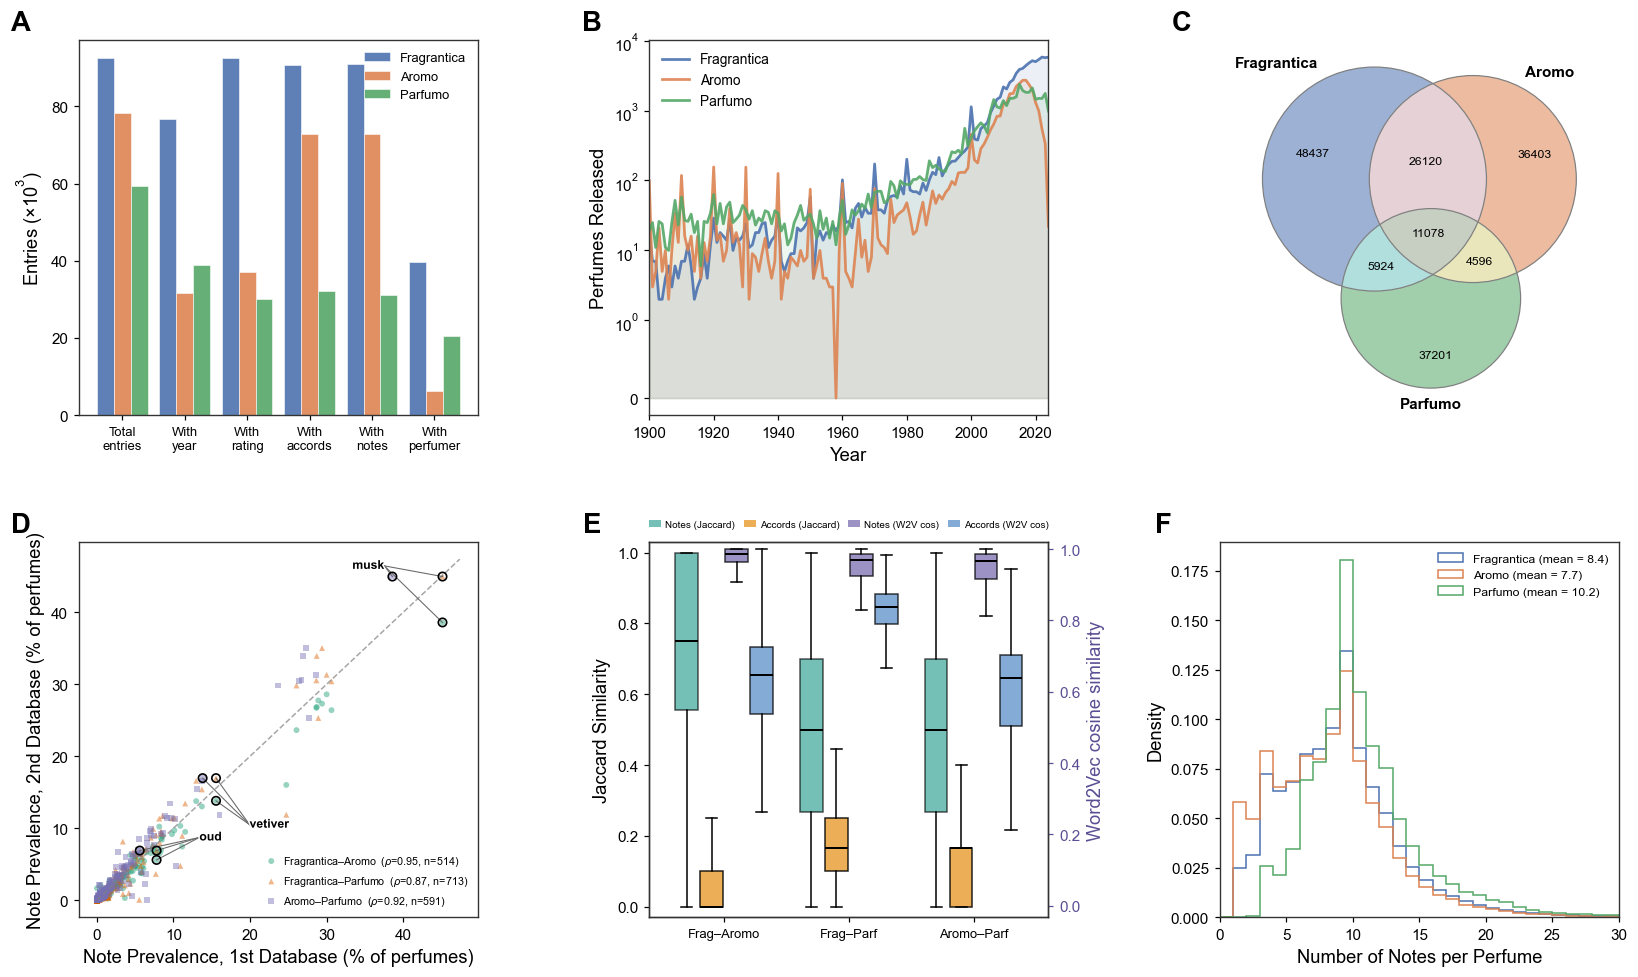

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for (label, fn), ax in zip(PANELS, axes.ravel()):
    fn(ax)
    ax.text(-0.12, 1.08, label, transform=ax.transAxes,
            fontsize=18, fontweight="bold", va="top", ha="right")
fig.tight_layout(w_pad=2.5, h_pad=3.0)
fig.savefig(f"{OUTPUT_DIR}/Figure_S1.pdf")
plt.show()

## 6. Summary statistics  table

Side-by-side summary of the three datasets (catalogue size, field coverage, categorical metadata, crowdsourced ratings/votes, and user contributions including resemblance annotations), with the cross-dataset union where meaningful. Also reports the pairwise shared-note agreement behind panels D-E and writes a LaTeX table to `output/Table_S1.tex`.

In [5]:
DASH = "—"
def C(n):
    return f"{int(n):,}"

def perfumer_set_fg(series):
    from utils.utils import parse_perfumer
    s = set()
    for cell in series.dropna():
        s.update(match_norm(p) for p in parse_perfumer(cell))
    return s - {""}

def perfumer_set_list(series):
    s = set()
    for lst in series:
        s.update(match_norm(p) for p in lst)
    return s - {""}

def perfumer_set_parfumo(series):
    s = set()
    for cell in series.dropna():
        for p in str(cell).split(","):
            s.add(match_norm(p.split(" / ")[0]))
    return s - {""}

perf = {
    "Fragrantica": perfumer_set_fg(fg["perfumer"]),
    "Aromo":       perfumer_set_list(ar["perfumers_list"]),
    "Parfumo":     perfumer_set_parfumo(pm["Perfumers"]),
}
brand = {
    "Fragrantica": {match_norm(b) for b in fg["brand"].dropna()} - {""},
    "Aromo":       {match_norm(b) for b in ar["brand"].dropna()} - {""},
    "Parfumo":     {match_norm(b) for b in pm["Brand"].dropna()} - {""},
}
notes_set    = {k: set(DATA[k]["note_counter"]) for k in ORDER}
accords_set  = {k: set(DATA[k]["acc_counter"])  for k in ORDER}
rating10     = {"Fragrantica": fg_rating10, "Aromo": ar_rating10, "Parfumo": pm_rating10}
year_col     = {"Fragrantica": fg["year"], "Aromo": ar["year"], "Parfumo": pm["Release_Year"]}
perfume_keys = {k: DATA[k]["keys"] for k in ORDER}

yr_range = lambda s: f"{int(s.min())}–{int(s.max())}"
union    = lambda d: set().union(*d.values())

def _sum_votes(s):
    """Sum the vote counts in a Fragrantica rating dict, e.g. {"1":2,"2":5,...}."""
    if pd.isna(s):
        return 0
    try:
        d = ast.literal_eval(str(s).replace('""', '"'))
        return int(sum(float(v) for v in d.values()))
    except Exception:
        return 0

def _list_len(s):
    if pd.isna(s):
        return 0
    try:
        v = ast.literal_eval(str(s))
        return len(v) if isinstance(v, list) else 0
    except Exception:
        return 0

fg_rating_votes    = int(fg["rating"].apply(_sum_votes).sum())
fg_sillage_votes   = int(fg["sillage_rating"].apply(_sum_votes).sum())
fg_longevity_votes = int(fg["longevity_rating"].apply(_sum_votes).sum())
fg_price_votes     = int(fg["price_rating"].apply(_sum_votes).sum())
fg_gender_votes    = int(fg["gender_rating"].apply(_sum_votes).sum())
fg_collect_votes   = int(fg["relation"].apply(_sum_votes).sum())
fg_note_votes      = int(pd.to_numeric(fg["Total_votes"], errors="coerce").fillna(0).sum())

_remind_len        = fg["this_perfume_reminds_ids"].apply(_list_len)
fg_resem_perfumes  = int((_remind_len > 0).sum())
fg_resem_total     = int(_remind_len.sum())

fg_genders, fg_countries = fg["gender"].nunique(), fg["Country"].nunique()
fg_segments = fg["Type"].nunique()
fg_name = int(fg["perfume name"].notna().sum()); ar_name = int(ar["name"].notna().sum()); pm_name = int(pm["Name"].notna().sum())

ar_rating_votes = int(pd.to_numeric(ar["rating_count_num"], errors="coerce").fillna(0).sum())
ar_segments, ar_conc = ar["segment"].nunique(), ar["type"].nunique()
def _nonempty_list(s):
    if pd.isna(s):
        return False
    try:
        v = ast.literal_eval(str(s))
        return isinstance(v, list) and len(v) > 0
    except Exception:
        return False
ar_user_notes = int(ar["users_notes"].apply(_nonempty_list).sum())

pm_rating_votes = int(pd.to_numeric(pm["Rating_Count"], errors="coerce").fillna(0).sum())
pm_conc = pm["Concentration"].nunique()

cov = lambda i: [C(COVERAGE[k][i]) for k in ORDER]

ROWS = [
    ("Perfumes",                   *[C(DATA[k]["n"]) for k in ORDER], C(len(union(perfume_keys)))),
    ("Brands",                     *[C(len(brand[k])) for k in ORDER], C(len(union(brand)))),
    ("Perfumers",                  *[C(len(perf[k])) for k in ORDER], C(len(union(perf)))),
    ("Unique canonical notes",     *[C(len(notes_set[k])) for k in ORDER], C(len(union(notes_set)))),
    ("Unique canonical accords",   *[C(len(accords_set[k])) for k in ORDER], C(len(union(accords_set)))),
    ("Year range",                 *[yr_range(year_col[k]) for k in ORDER],
                                   f"{min(int(year_col[k].min()) for k in ORDER)}–"
                                   f"{max(int(year_col[k].max()) for k in ORDER)}"),
    ("With release year",          *cov(1), DASH),
    ("With overall rating",        *cov(2), DASH),
    ("With main accords",          *cov(3), DASH),
    ("With notes / fragrance pyramid", *cov(4), DASH),
    ("With perfumer",              *cov(5), DASH),
    ("Perfumes with names",        C(fg_name), C(ar_name), C(pm_name), DASH),
    ("Gender categories",          C(fg_genders), DASH, DASH, DASH),
    ("Countries of origin",        C(fg_countries), DASH, DASH, DASH),
    ("Market segments",            C(fg_segments), C(ar_segments), DASH, DASH),
    ("Concentration types",        DASH, C(ar_conc), C(pm_conc), DASH),
    ("Mean rating (1–10 scale)",   *[f"{rating10[k].mean():.2f}" for k in ORDER], DASH),
    ("Overall rating votes",       C(fg_rating_votes), C(ar_rating_votes), C(pm_rating_votes), DASH),
    ("Note votes",                 C(fg_note_votes), DASH, DASH, DASH),
    ("Sillage votes",              C(fg_sillage_votes), DASH, DASH, DASH),
    ("Longevity votes",            C(fg_longevity_votes), DASH, DASH, DASH),
    ("Price-value votes",          C(fg_price_votes), DASH, DASH, DASH),
    ("Gender votes",               C(fg_gender_votes), DASH, DASH, DASH),
    ("Collection signals (had/have/want)", C(fg_collect_votes), DASH, DASH, DASH),
    ("Perfumes with user-submitted notes",     DASH, C(ar_user_notes), DASH, DASH),
    ("Perfumes with resemblance annotations",  C(fg_resem_perfumes), DASH, DASH, DASH),
    ("Total resemblance annotations",          C(fg_resem_total), DASH, DASH, DASH),
]

summary_df = pd.DataFrame(ROWS, columns=["Metric", "Fragrantica",
                                         "Aromo", "Parfumo", "Total (union)"]
                          ).set_index("Metric")

pair_rows = []
for a, b in PAIRS:
    d = _shared_note_frame(a, b)
    rho, _ = spearmanr(d["xa"], d["yb"])
    note_j, acc_j = MATCHED[(a, b)]
    pair_rows.append({
        "Pair": f"{a} ∩ {b}",
        "Shared notes": C(len(d)),
        "Prevalence ρ": f"{rho:.3f}",
        "Matched perfumes": C(len(note_j)),
        "Note Jaccard (median)": f"{np.median(note_j):.3f}",
        "Accord Jaccard (median)": f"{np.median(acc_j):.3f}",
    })
pairs_df = pd.DataFrame(pair_rows).set_index("Pair")

from IPython.display import display
print("Dataset summary"); display(summary_df)
print("Pairwise shared-note agreement (panels D–E)"); display(pairs_df)

def _tex(x):
    return str(x).replace("–", "--").replace("—", "---").replace("&", r"\&")

latex = (r"\begin{table}[ht]" "\n" r"\centering" "\n" r"\small" "\n"
         r"\caption{Summary statistics of the three perfume datasets after deduplication and "
         r"semantic normalisation of notes and accords. Vote counts are crowdsourced totals "
         r"summed over all perfumes; \emph{resemblance annotations} are Fragrantica's "
         r"`this perfume reminds me of' links. The \textbf{Total} column reports unique entities "
         r"across all three datasets after cross-dataset name matching; a dash (---) marks a "
         r"metric not available in that dataset.}" "\n"
         r"\label{tab:dataset_comparison}" "\n"
         r"\begin{tabular}{lcccc}" "\n" r"\toprule" "\n"
         r"\textbf{Metric} & \textbf{Fragrantica} & \textbf{Aromo} & \textbf{Parfumo} & \textbf{Total} \\" "\n"
         r"\midrule" "\n")
for m, f, a, p, t in ROWS:
    latex += " & ".join(_tex(x) for x in (m, f, a, p, t)) + r" \\" + "\n"
latex += r"\bottomrule" "\n" r"\end{tabular}" "\n" r"\end{table}"

tex_path = f"{OUTPUT_DIR}/Table_S1.tex"
with open(tex_path, "w") as f:
    f.write(latex)
print(f"\nLaTeX table written to {tex_path}\n")

Dataset summary


,Fragrantica,Aromo,Parfumo,Total (union)
Metric,,,,
Perfumes,"92,589","78,409","59,280","169,759"
Brands,"4,780","5,936","1,450","8,332"
Perfumers,"2,475",548,"1,258","3,050"
Unique canonical notes,"1,553","1,394","3,989","5,510"
Unique canonical accords,91,23,21,111
Year range,1533–2025,1792–2024,1709–2024,1533–2025
With release year,"76,632","31,619","38,984",—
With overall rating,"92,589","37,006","30,027",—
With main accords,"90,806","72,846","32,196",—


Pairwise shared-note agreement (panels D–E)


,Shared notes,Prevalence ρ,Matched perfumes,Note Jaccard (median),Accord Jaccard (median)
Pair,,,,,
Fragrantica ∩ Aromo,514,0.946,"35,962",0.750,0.000
Fragrantica ∩ Parfumo,713,0.871,"10,608",0.500,0.167
Aromo ∩ Parfumo,591,0.924,"9,071",0.500,0.167



LaTeX table written to ../output/Table_S1.tex

